# Clue-giver attempt timestamps

Reads `transcripts_all.csv` and, per trial, extracts the **timestamps of each clue-giver attempt**
to explain the target term — so those intervals can be used to slice and compare the multimodal
signals (merged video, motion tracking, acoustics, sway) attempt-by-attempt. `start`/`end` are
seconds from trial start, the same clock as the other modalities.

**Definitions (as chosen):**
- **Turns are chronological.** All of a trial's segments are ordered by `start`; a new turn begins
  whenever `role` changes. A guesser interjection (even overlapping) ends the current clue-giver
  attempt.
- **Attempts run up to the correct guess.** An attempt is a clue-giver turn that *starts before* the
  first mention of the target word (the guess). Trials where the target word never appears keep all
  clue-giver turns and are flagged `guessed = False`.

Outputs (written next to this notebook): `clue_giver_attempts.csv` (one row per attempt) and
`trial_turntaking_summary.csv` (one row per trial).

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
SRC = HERE / "transcripts_all.csv"
ATTEMPTS_CSV = HERE / "clue_giver_attempts.csv"
SUMMARY_CSV = HERE / "trial_turntaking_summary.csv"

df = pd.read_csv(SRC)
df["text"] = df["text"].fillna("").astype(str)
print(f"{len(df)} segment rows across {df['trial_id'].nunique()} trials")

def says_target(text, target):
    """True if `text` contains the target word (case-insensitive, exact or simple plural/singular)."""
    target = str(target).lower()
    for tok in re.findall(r"[a-z']+", str(text).lower()):
        if tok == target or (tok.rstrip("s") == target.rstrip("s") and abs(len(tok) - len(target)) <= 2):
            return True
    return False

623 segment rows across 120 trials


In [2]:
def glue_turns(trial):
    """Order a trial's segments by time and glue consecutive same-role segments into turns."""
    trial = trial.sort_values(["start", "end"]).reset_index(drop=True)
    turns = []
    for r in trial.itertuples(index=False):
        if turns and r.role == turns[-1]["role"]:
            turns[-1]["end"] = max(turns[-1]["end"], r.end)
            turns[-1]["text"] = (turns[-1]["text"] + " " + r.text).strip()
            turns[-1]["n_segments"] += 1
        else:
            turns.append({"role": r.role, "participant_id": r.participant_id,
                          "start": r.start, "end": r.end, "text": r.text.strip(), "n_segments": 1})
    return turns


def guess_time_of(trial):
    """Start time of the first segment (chronological) whose text contains the target word, else None."""
    target = trial["target_word"].iloc[0]
    hits = trial[trial["text"].apply(lambda t: says_target(t, target))]
    return float(hits["start"].min()) if len(hits) else None


def process_trial(trial):
    """Return (attempt_rows, summary_row) for one trial."""
    meta = trial.iloc[0]
    turns = glue_turns(trial)
    gtime = guess_time_of(trial)
    guessed = gtime is not None
    cutoff = gtime if guessed else np.inf

    cg_id = trial.loc[trial.role == "clue_giver", "participant_id"]
    gu_id = trial.loc[trial.role == "guesser", "participant_id"]
    cg_id = int(cg_id.iloc[0]) if len(cg_id) else None
    gu_id = int(gu_id.iloc[0]) if len(gu_id) else None

    # clue-giver attempts = clue-giver turns starting before the guess
    attempts = [t for t in turns if t["role"] == "clue_giver" and t["start"] < cutoff]
    kept_turns = [t for t in turns if t["start"] < cutoff]      # all turns before the guess
    turntakes = sum(1 for a, b in zip(kept_turns, kept_turns[1:]) if a["role"] != b["role"])

    guess_text = ""
    if guessed:
        g = trial[trial["text"].apply(lambda t: says_target(t, meta.target_word))].sort_values("start")
        guess_text = g["text"].iloc[0]

    attempt_rows = []
    for i, t in enumerate(attempts, start=1):
        attempt_rows.append({
            "trial_id": meta.trial_id, "pair_id": meta.pair_id, "condition": meta.condition,
            "target_word": meta.target_word, "clue_giver_id": cg_id,
            "attempt_idx": i, "n_attempts": len(attempts),
            "start": round(t["start"], 3), "end": round(t["end"], 3),
            "duration": round(t["end"] - t["start"], 3),
            "n_segments": t["n_segments"], "text": t["text"],
        })

    summary_row = {
        "trial_id": meta.trial_id, "pair_id": meta.pair_id, "condition": meta.condition,
        "target_word": meta.target_word, "clue_giver_id": cg_id, "guesser_id": gu_id,
        "n_clue_giver_attempts": len(attempts), "n_turns_total": len(kept_turns),
        "n_turntakes": turntakes, "guessed": guessed,
        "guess_time": round(gtime, 3) if guessed else None, "guess_text": guess_text,
    }
    return attempt_rows, summary_row

In [3]:
attempt_rows, summary_rows = [], []
for _tid, trial in df.groupby("trial_id", sort=True):
    a, s = process_trial(trial)
    attempt_rows.extend(a)
    summary_rows.append(s)

attempts = pd.DataFrame(attempt_rows)
summary = pd.DataFrame(summary_rows)

attempts.to_csv(ATTEMPTS_CSV, index=False)
summary.to_csv(SUMMARY_CSV, index=False)

print(f"{len(summary)} trials  |  {int(summary['guessed'].sum())} guessed, "
      f"{int((~summary['guessed']).sum())} not guessed")
print(f"{len(attempts)} clue-giver attempts total "
      f"(mean {summary['n_clue_giver_attempts'].mean():.1f} per trial)")
print(f"wrote {ATTEMPTS_CSV.name} and {SUMMARY_CSV.name}")
attempts.head()

120 trials  |  64 guessed, 56 not guessed
185 clue-giver attempts total (mean 1.5 per trial)
wrote clue_giver_attempts.csv and trial_turntaking_summary.csv


,trial_id,pair_id,condition,target_word,clue_giver_id,attempt_idx,n_attempts,start,end,duration,n_segments,text
0,103_203_12_1_20250113_152455_doughnut_board,103_203,board,doughnut,103,1,1,1.01,13.79,12.78,4,"Okay, it's like something sweet like a Like th..."
1,103_203_13_1_20250113_152513_spinach_board,103_203,board,spinach,103,1,1,2.80,13.80,11.00,1,"Uh, oh no. It's like, I think Lattice, but not..."
2,103_203_14_1_20250113_152536_balloon_board,103_203,board,balloon,103,1,2,2.61,18.61,16.00,6,"It's latex. You, um... No, you sort of like......"
3,103_203_14_1_20250113_152536_balloon_board,103_203,board,balloon,103,2,2,20.61,22.61,2.00,1,Yeah.
4,103_203_15_1_20250113_152557_bacon_board,103_203,board,bacon,103,1,3,1.20,6.08,4.88,1,"Okay, it's a type of meat comes from an animal..."


## Spot check

In [4]:
for key in ("doughnut_board", "exam_ground"):
    tid = next(t for t in summary["trial_id"] if key in t)
    row = summary[summary.trial_id == tid].iloc[0]
    print(f"\n{tid}\n  target={row.target_word!r}  guessed={row.guessed}  "
          f"guess_time={row.guess_time}  attempts={row.n_clue_giver_attempts}  turntakes={row.n_turntakes}")
    print(attempts[attempts.trial_id == tid][["attempt_idx", "start", "end", "duration", "text"]]
          .to_string(index=False))


103_203_12_1_20250113_152455_doughnut_board
  target='doughnut'  guessed=True  guess_time=14.46  attempts=1  turntakes=0
 attempt_idx  start   end  duration                                                                                                                text
           1   1.01 13.79     12.78 Okay, it's like something sweet like a Like think bread, but sweet Like that and then has another one in the middle

103_203_30_1_20250113_153310_exam_ground
  target='exam'  guessed=False  guess_time=nan  attempts=1  turntakes=0
 attempt_idx  start   end  duration                                                                                                       text
           1   0.88 12.88      12.0 You have to sit them. You don't really like them. They come at the end of the year in university and yeah.


## Distribution of clue-giver attempts per trial

attempts per trial — mean 1.5, median 1, range 0–8


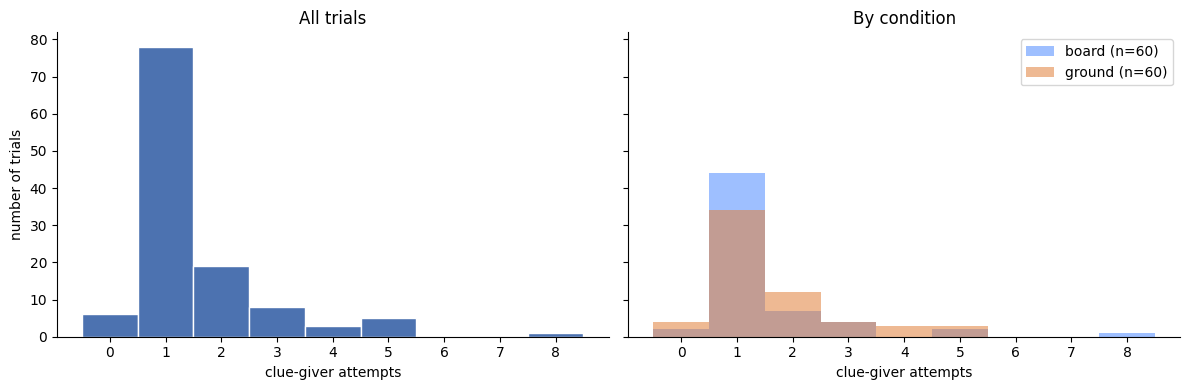

In [5]:
n = summary["n_clue_giver_attempts"]
print(f"attempts per trial — mean {n.mean():.1f}, median {n.median():.0f}, range {n.min()}–{n.max()}")

bins = range(int(n.min()), int(n.max()) + 2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(n, bins=bins, align="left", edgecolor="white", color="#4C72B0")
axes[0].set_title("All trials")
axes[0].set_xlabel("clue-giver attempts"); axes[0].set_ylabel("number of trials")

colors = {"board": "#4f8cff", "ground": "#e0803a"}
for cond, sub in summary.groupby("condition"):
    axes[1].hist(sub["n_clue_giver_attempts"], bins=bins, align="left", alpha=0.55,
                 label=f"{cond} (n={len(sub)})", color=colors.get(cond))
axes[1].set_title("By condition"); axes[1].set_xlabel("clue-giver attempts"); axes[1].legend()

for ax in axes:
    ax.set_xticks(list(bins)[:-1]); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Slice a multimodal series by attempt

`attempt_intervals(trial_id)` returns the attempt intervals; `assign_attempts(series, time_col,
trial_id, time_unit)` tags each row of any time-series with the attempt it falls in (`attempt`
column, NaN outside). The demo below slices the clue-giver's wrist speed (from motion tracking) by
attempt — swap in any series (e.g. `sway`, acoustic `envelope`/`f0`) using its own time column and
unit to compare the per-attempt dynamics.

103_203_15_1_20250113_152557_bacon_board
per-attempt clue-giver wrist speed:
         mean_speed  peak_speed  n_frames
attempt                                  
1.0          0.0440      0.1307       147
2.0          0.0834      0.3007       158
3.0          0.1624      0.6677        75


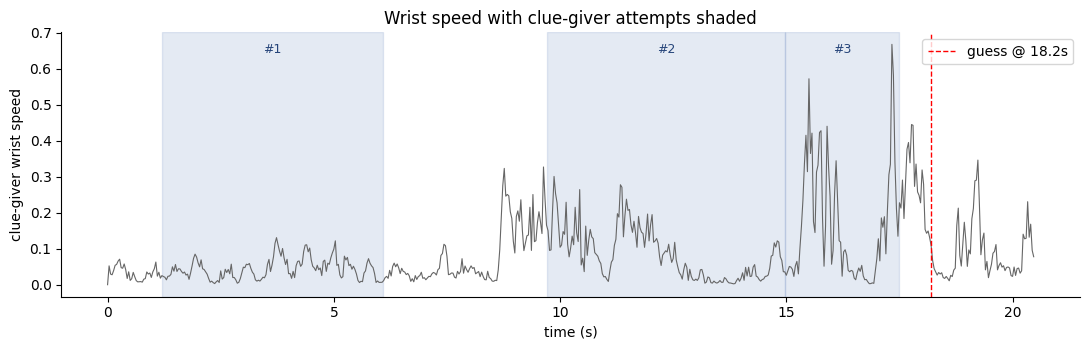

In [6]:
# ---- Slice a multimodal series by clue-giver attempt ----------------------
CORPUS = HERE.parent                                   # .../Datasets/BalanceCorpus
MOTION = CORPUS / "motiontracking" / "Output_TimeSeries"

def attempt_intervals(trial_id):
    """Attempts for one trial: DataFrame [attempt_idx, start, end, duration, text]."""
    cols = ["attempt_idx", "start", "end", "duration", "text"]
    return (attempts.loc[attempts.trial_id == trial_id, cols]
            .sort_values("start").reset_index(drop=True))

def assign_attempts(series, time_col, trial_id, time_unit="s"):
    """Copy of `series` with a `t_sec` column and an `attempt` column (the attempt_idx each row
    falls in, NaN outside any attempt). `time_unit` is 's' or 'ms' for the series' time column."""
    s = series.copy()
    t = s[time_col].to_numpy() / (1000.0 if time_unit == "ms" else 1.0)
    s["t_sec"] = t
    s["attempt"] = np.nan
    for r in attempt_intervals(trial_id).itertuples(index=False):
        s.loc[(t >= r.start) & (t < r.end), "attempt"] = r.attempt_idx
    return s


# --- demo: clue-giver wrist speed (a gesture signal) sliced per attempt -----
DEMO_TRIAL = "103_203_15_1_20250113_152557_bacon_board"   # 3 attempts, guessed

body = pd.read_csv(MOTION / f"{DEMO_TRIAL}_clueGiver_cam01_body.csv")
_t = body["time"].to_numpy() / 1000.0
def _sp(x, y):
    dx = np.diff(x, prepend=x[0]); dy = np.diff(y, prepend=y[0])
    return np.sqrt(dx * dx + dy * dy)
_dt = np.diff(_t, prepend=_t[0]); _dt[_dt == 0] = np.nan
body["wrist_speed"] = np.nan_to_num(
    (_sp(body["X_LEFT_WRIST"].to_numpy(), body["Y_LEFT_WRIST"].to_numpy())
     + _sp(body["X_RIGHT_WRIST"].to_numpy(), body["Y_RIGHT_WRIST"].to_numpy())) / 2 / _dt)

tagged = assign_attempts(body[["time", "wrist_speed"]], "time", DEMO_TRIAL, time_unit="ms")

print(f"{DEMO_TRIAL}\nper-attempt clue-giver wrist speed:")
print(tagged.dropna(subset=["attempt"]).groupby("attempt")["wrist_speed"]
      .agg(mean_speed="mean", peak_speed="max", n_frames="count").round(4).to_string())

iv = attempt_intervals(DEMO_TRIAL)
gt = summary.loc[summary.trial_id == DEMO_TRIAL, "guess_time"].iloc[0]
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(tagged["t_sec"], tagged["wrist_speed"], color="0.4", lw=0.8)
for r in iv.itertuples(index=False):
    ax.axvspan(r.start, r.end, alpha=0.15, color="#4C72B0")
    ax.text((r.start + r.end) / 2, ax.get_ylim()[1] * 0.92, f"#{int(r.attempt_idx)}",
            ha="center", fontsize=9, color="#26457a")
ax.axvline(gt, color="red", ls="--", lw=1, label=f"guess @ {gt:.1f}s")
ax.set_xlabel("time (s)"); ax.set_ylabel("clue-giver wrist speed")
ax.set_title("Wrist speed with clue-giver attempts shaded")
ax.legend(loc="upper right"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Export ELAN files for the DIMS app

Writes one `.eaf` per trial into `dims/assets/elan/{trial_id}.eaf` — the path the DIMS dashboard
reads. Each file has two tiers:

- **`clue_giver_attempts`** — one annotation per attempt, spanning its interval, labelled `attempt N`.
- **`guess`** — the segment where the target word is first said, labelled `guess: <target_word>`.

Trials with no attempts *and* no guess are skipped (an EAF with no annotations would error in DIMS).
For the tab to appear, `dims/config.json` needs `"include_elan": true`.

In [7]:
import xml.sax.saxutils as sx

# ---- Write ELAN (.eaf) files for the DIMS app: attempts + guess ------------
ELAN_DIR = HERE / "dims" / "assets" / "elan"     # DIMS reads assets/elan/{videoID}.eaf

def guess_span(trial_id):
    """(start, end) of the first segment containing the target word, else None."""
    t = df[df.trial_id == trial_id]
    target = t["target_word"].iloc[0]
    hits = t[t["text"].apply(lambda x: says_target(x, target))].sort_values("start")
    if not len(hits):
        return None
    r = hits.iloc[0]
    return float(r.start), float(r.end)


def write_eaf(trial_id, out_dir=ELAN_DIR):
    """One .eaf per trial: a 'clue_giver_attempts' tier and a 'guess' tier."""
    iv = attempt_intervals(trial_id)
    gs = guess_span(trial_id)
    target = summary.loc[summary.trial_id == trial_id, "target_word"].iloc[0]

    tiers = {}
    if len(iv):
        tiers["clue_giver_attempts"] = [
            (r.start, r.end, f"attempt {int(r.attempt_idx)}") for r in iv.itertuples(index=False)
        ]
    if gs:
        tiers["guess"] = [(gs[0], gs[1], f"guess: {target}")]
    if not tiers:
        return False                                   # nothing to annotate

    slots = {}                                         # ms -> slot id
    def slot(t_sec):
        ms = int(round(t_sec * 1000))
        if ms not in slots:
            slots[ms] = f"ts{len(slots) + 1}"
        return slots[ms]

    aid, tier_xml = 0, []
    for tier_id, anns in tiers.items():
        rows = []
        for s, e, val in anns:
            aid += 1
            r1, r2 = slot(s), slot(e)
            rows.append(
                "      <ANNOTATION>\n"
                f'        <ALIGNABLE_ANNOTATION ANNOTATION_ID="a{aid}" '
                f'TIME_SLOT_REF1="{r1}" TIME_SLOT_REF2="{r2}">\n'
                f"          <ANNOTATION_VALUE>{sx.escape(val)}</ANNOTATION_VALUE>\n"
                "        </ALIGNABLE_ANNOTATION>\n"
                "      </ANNOTATION>"
            )
        tier_xml.append(
            f'  <TIER LINGUISTIC_TYPE_REF="default" TIER_ID="{sx.escape(tier_id)}">\n'
            + "\n".join(rows) + "\n  </TIER>"
        )

    slot_xml = "\n".join(f'    <TIME_SLOT TIME_SLOT_ID="{sid}" TIME_VALUE="{ms}"/>'
                         for ms, sid in sorted(slots.items()))
    xml = "\n".join([
        '<?xml version="1.0" encoding="UTF-8"?>',
        '<ANNOTATION_DOCUMENT AUTHOR="BalanceCorpus turntaking" FORMAT="3.0" VERSION="3.0"'
        ' xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance"'
        ' xsi:noNamespaceSchemaLocation="http://www.mpi.nl/tools/elan/EAFv3.0.xsd">',
        '  <HEADER TIME_UNITS="milliseconds"/>',
        "  <TIME_ORDER>", slot_xml, "  </TIME_ORDER>",
        *tier_xml,
        '  <LINGUISTIC_TYPE LINGUISTIC_TYPE_ID="default" TIME_ALIGNABLE="true"/>',
        "</ANNOTATION_DOCUMENT>",
    ])
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / f"{trial_id}.eaf").write_text(xml, encoding="utf-8")
    return True


written = sum(write_eaf(t) for t in summary["trial_id"])
skipped = len(summary) - written
print(f"wrote {written} .eaf files to {ELAN_DIR}" + (f"  ({skipped} skipped: no attempts and no guess)" if skipped else ""))

# validate: every file is well-formed XML with at least one alignable annotation
import xml.etree.ElementTree as ET
bad = []
for p in sorted(ELAN_DIR.glob("*.eaf")):
    try:
        root = ET.parse(p).getroot()
        if not list(root.iter("ALIGNABLE_ANNOTATION")):
            bad.append((p.name, "no annotations"))
    except ET.ParseError as e:
        bad.append((p.name, str(e)))
print("validated:", len(list(ELAN_DIR.glob('*.eaf'))), "files |", "all OK" if not bad else f"PROBLEMS: {bad[:3]}")

wrote 120 .eaf files to /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/dims/assets/elan
validated: 120 files | all OK
